<a id="sec-top"></a>
# LSTM Deep Learning Model

**Notebook:** `04_modeling_lstm.ipynb`
**Input:** `data/processed/features.parquet` (from `02_feature_engineering.ipynb`)
**Output:** a trained LSTM model + scaler saved to `models/`, evaluated against
the classical models from `03_modeling_classical.ipynb`

### Purpose of this notebook
Build a deep learning challenger to SARIMA/Prophet. Unlike those models
(fit **per store**, one model per time series), this notebook trains **one
global LSTM** across a pool of stores — deep learning models generally need
more data than a single store's ~2.5-year history provides, and pooling
lets the network learn shared patterns (weekly seasonality, promo response)
across stores while still using store-level features (type, assortment,
competition) to differentiate between them.

### Why this uses `features.parquet`, not the continuous per-store pull from Notebook 03
The LSTM needs the lag/rolling/calendar features engineered in Notebook 02 as
its input sequence — SARIMA/Prophet only needed a clean daily frequency of
raw sales. This is expected: different model families, different data shapes.

## Table of Contents
- [0. Setup](#sec-0)
- [1. Load Feature Table](#sec-1)
- [2. Select Store Sample](#sec-2)
- [3. Feature Scaling](#sec-3)
- [4. Build Sequences (Sliding Window)](#sec-4)
- [5. Train / Validation Split](#sec-5)
- [6. LSTM Architecture](#sec-6)
- [7. Train the Model](#sec-7)
- [8. Evaluate on Validation Set](#sec-8)
- [9. Compare Against Classical Models](#sec-9)
- [10. Save Model & Scaler](#sec-10)

<a id="sec-0"></a>
## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

import sys, os
sys.path.append(os.path.abspath(".."))
from src.evaluation.metrics import evaluate_forecast

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

<a id="sec-1"></a>
## 1. Load Feature Table

Loads the model-ready table built in `02_feature_engineering.ipynb` already
has calendar, competition, promo, lag, and rolling features, plus the
chronological split column.

In [5]:
df = pd.read_parquet("../data/processed/features.parquet")
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df[["store_id", "date", "sales", "split"]].head()

(813172, 51)


,store_id,date,sales,split
0,1,2013-02-04,7032,train
1,1,2013-02-05,6049,train
2,1,2013-02-06,6140,train
3,1,2013-02-07,5499,train
4,1,2013-02-08,5681,train


<a id="sec-2"></a>
## 2. Select Store Sample

Training on all 1,115 stores is possible but slow to iterate on. Using the same
5-store sample from `03_modeling_classical.ipynb` Section 7.

In [6]:
SAMPLE_STORE_IDS = [1, 2, 85, 262, 733]  # same sample as 03_modeling_classical.ipynb Section 7

df_sample = df[df["store_id"].isin(SAMPLE_STORE_IDS)].copy()
df_sample = df_sample.sort_values(["store_id", "date"]).reset_index(drop=True)
print(df_sample.shape)
df_sample["store_id"].value_counts()

(4251, 51)


store_id
85     914
262    914
733    914
2      756
1      753
Name: count, dtype: int64

---

<a id="sec-3"></a>
## 3. Feature Scaling

In [7]:
FEATURE_COLS = [
    "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos",
    "is_weekend", "promo", "school_holiday", "is_promo2_active", "promo_start_flag",
    "competition_distance", "months_since_competition_open",
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_28",
    "sales_rolling_mean_7", "sales_rolling_mean_30",
    "sales_rolling_std_7", "sales_rolling_min_7", "sales_rolling_max_7",
]
# Include one-hot store_type/assortment columns if present
FEATURE_COLS += [c for c in df_sample.columns if c.startswith("store_type_") or c.startswith("assortment_")]

TARGET_COL = "sales"

print(f"Using {len(FEATURE_COLS)} input features")

Using 27 input features


In [8]:
train_mask = df_sample["split"] == "train"

feature_scaler = MinMaxScaler()
feature_scaler.fit(df_sample.loc[train_mask, FEATURE_COLS])

target_scaler = MinMaxScaler()
target_scaler.fit(df_sample.loc[train_mask, [TARGET_COL]])

df_sample[FEATURE_COLS] = feature_scaler.transform(df_sample[FEATURE_COLS])
df_sample[TARGET_COL + "_scaled"] = target_scaler.transform(df_sample[[TARGET_COL]])

df_sample[FEATURE_COLS + [TARGET_COL, TARGET_COL + "_scaled"]].head()

,day_of_week_sin,day_of_week_cos,month_sin,month_cos,is_weekend,promo,school_holiday,is_promo2_active,promo_start_flag,competition_distance,...,sales_rolling_max_7,store_type_a,store_type_b,store_type_c,store_type_d,assortment_a,assortment_b,assortment_c,sales,sales_scaled
0,0.900969,8.019377e-01,0.933013,0.75,0.0,1.0,0.0,0.0,1.0,0.538462,...,0.057524,0.0,0.0,1.0,0.0,1.0,0.0,0.0,7032,0.138929
1,1.000000,3.568959e-01,0.933013,0.75,0.0,1.0,0.0,0.0,0.0,0.538462,...,0.088084,0.0,0.0,1.0,0.0,1.0,0.0,0.0,6049,0.112219
2,0.722521,5.551115e-17,0.933013,0.75,0.0,1.0,0.0,0.0,0.0,0.538462,...,0.088084,0.0,0.0,1.0,0.0,1.0,0.0,0.0,6140,0.114692
3,0.277479,0.000000e+00,0.933013,0.75,0.0,1.0,0.0,0.0,0.0,0.538462,...,0.088084,0.0,0.0,1.0,0.0,1.0,0.0,0.0,5499,0.097275
4,0.000000,3.568959e-01,0.933013,0.75,0.0,1.0,0.0,0.0,0.0,0.538462,...,0.088084,0.0,0.0,1.0,0.0,1.0,0.0,0.0,5681,0.102220


<a id="sec-4"></a>
## 4. Build Sequences (Sliding Window)

LSTMs need input shaped as (samples, timesteps, features). For each store,
slide a window of LOOKBACK days across its (scaled) feature history; the
target is the next day's scaled sales. Sequences are built per store
and then pooled together, so the model sees many stores' patterns but never
mixes one store's days into another store's window.

In [9]:
LOOKBACK = 14  # days of history the model looks at to predict the next day 

def create_sequences(store_df: pd.DataFrame, feature_cols: list, target_col: str, lookback: int):
    """Returns X (n, lookback, n_features), y (n,), and the target date for each sample."""
    values = store_df[feature_cols].values
    target = store_df[target_col].values
    dates = store_df["date"].values

    X, y, target_dates = [], [], []
    for i in range(lookback, len(store_df)):
        X.append(values[i - lookback:i])
        y.append(target[i])
        target_dates.append(dates[i])

    return np.array(X), np.array(y), np.array(target_dates)

In [10]:
all_X, all_y, all_dates, all_store_ids = [], [], [], []

for store_id, store_df in df_sample.groupby("store_id"):
    store_df = store_df.sort_values("date").reset_index(drop=True)
    X, y, dates = create_sequences(store_df, FEATURE_COLS, TARGET_COL + "_scaled", LOOKBACK)
    all_X.append(X)
    all_y.append(y)
    all_dates.append(dates)
    all_store_ids.extend([store_id] * len(y))

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
dates_all = np.concatenate(all_dates, axis=0)
store_ids_all = np.array(all_store_ids)

print("X shape:", X_all.shape, "  (samples, timesteps, features)")
print("y shape:", y_all.shape)

X shape: (4181, 14, 27)   (samples, timesteps, features)
y shape: (4181,)


<a id="sec-5"></a>
## 5. Train / Validation Split (Sequence-Aware)

Split by the **target date** of each sequence, using the same split_date
convention as the other notebooks.

In [11]:
split_date = df_sample.loc[df_sample["split"] == "train", "date"].max()
print("Split date:", split_date.date())

train_idx = dates_all <= np.datetime64(split_date)
val_idx = ~train_idx

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
dates_val = dates_all[val_idx]
store_ids_val = store_ids_all[val_idx]

print(f"Train sequences: {len(X_train)}   Validation sequences: {len(X_val)}")

Split date: 2015-06-19
Train sequences: 3983   Validation sequences: 198


---

<a id="sec-6"></a>
## 6. LSTM Architecture

A modest two-layer LSTM — enough capacity to learn weekly/monthly patterns
across a handful of pooled stores without overfitting on a relatively small
sample.

In [12]:
# We can add more layers in LSTM to increase prediction accuracy
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, len(FEATURE_COLS))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),  # predicts scaled sales for the next day
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

C:\Users\3366a\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 14, 64)              │          23,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,513 (142.63 KB)

 Trainable params: 36,513 (142.63 KB)

 Non-trainable params: 0 (0.00 B)

---

<a id="sec-7"></a>
## 7. Train the Model


In [13]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0098 - mae: 0.0686 - val_loss: 0.0046 - val_mae: 0.0454
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0065 - mae: 0.0552 - val_loss: 0.0042 - val_mae: 0.0420
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0061 - mae: 0.0529 - val_loss: 0.0041 - val_mae: 0.0417
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0057 - mae: 0.0507 - val_loss: 0.0040 - val_mae: 0.0428
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0056 - mae: 0.0502 - val_loss: 0.0038 - val_mae: 0.0431
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0049 - mae: 0.0470 - val_loss: 0.0033 - val_mae: 0.0398
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0046 - mae: 0.0454 - val_loss: 0.0027 - val_mae: 0.0346
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0045 - mae: 0.0446 - val_loss: 0.0024 - val_mae: 0.0335
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━

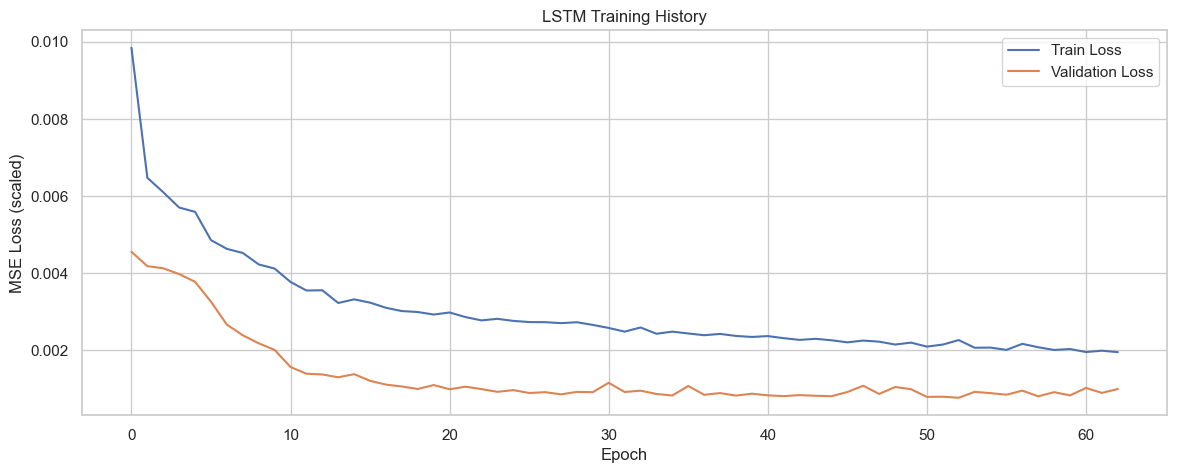

In [14]:
fig, ax = plt.subplots()
ax.plot(history.history["loss"], label="Train Loss")
ax.plot(history.history["val_loss"], label="Validation Loss")
ax.set_title("LSTM Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled)")
ax.legend()
plt.show()

<a id="sec-8"></a>
## 8. Evaluate on Validation Set

Predictions come out in **scaled** space inverse-transform back to real
sales units before computing MAE/RMSE/MAPE, so the numbers are directly
comparable to the classical models' metrics from Notebook 03.

In [15]:
y_pred_scaled = model.predict(X_val).flatten()

y_val_actual = target_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

lstm_metrics = evaluate_forecast(y_val_actual, y_pred_actual)
print("LSTM (pooled, all sample stores) metrics:", lstm_metrics)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
LSTM (pooled, all sample stores) metrics: {'MAE': 746.3102780737058, 'RMSE': 1019.6567868955726, 'MAPE': 8.35377754999259}


In [16]:
# Per-store breakdown 
results_df = pd.DataFrame({
    "store_id": store_ids_val,
    "date": dates_val,
    "actual": y_val_actual,
    "predicted": y_pred_actual,
})

per_store_mape = (
    results_df.groupby("store_id")
    .apply(lambda g: evaluate_forecast(g["actual"], g["predicted"])["MAPE"])
    .rename("lstm_mape")
)
per_store_mape

C:\Users\3366a\AppData\Local\Temp\ipykernel_2268\2224581869.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: evaluate_forecast(g["actual"], g["predicted"])["MAPE"])


store_id
1      10.220643
2      13.291301
85      7.931485
262     6.567774
733     4.729741
Name: lstm_mape, dtype: float64

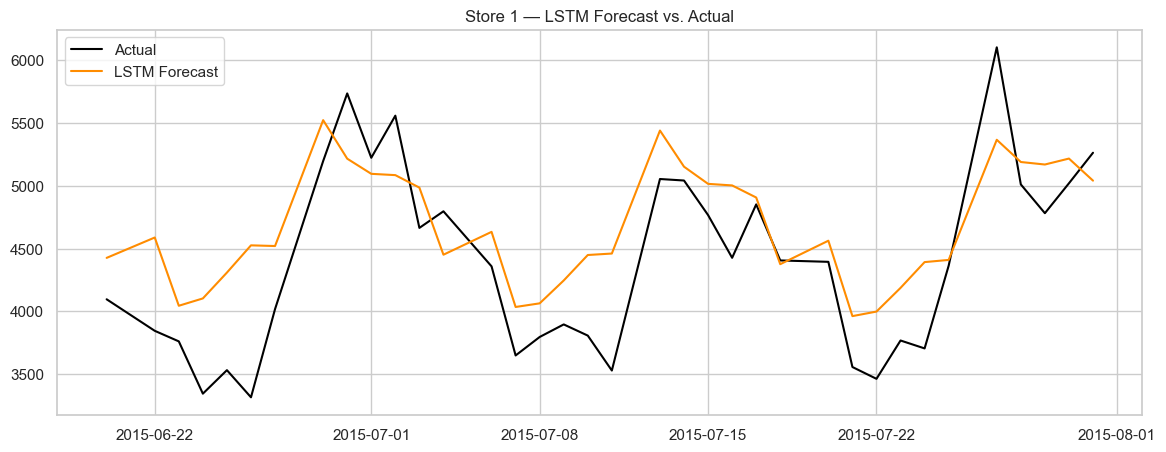

In [17]:
# Plot actual vs predicted for one store from the sample
plot_store = SAMPLE_STORE_IDS[0]
store_results = results_df[results_df["store_id"] == plot_store].sort_values("date")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(store_results["date"], store_results["actual"], label="Actual", color="black")
ax.plot(store_results["date"], store_results["predicted"], label="LSTM Forecast", color="darkorange")
ax.set_title(f"Store {plot_store} — LSTM Forecast vs. Actual")
ax.legend()
plt.show()

LSTM is preforming worst than SARMIA and Prophet on Store 1 with MAPE = 10.22


<a id="sec-9"></a>
## 9. Compare Against Classical Models


In [18]:
classical_results = pd.DataFrame({
    "store_id": [1, 2, 85, 262, 733],
    "naive_mape":   [16.152906, 26.329374, 14.632643, 9.056311, 10.968428],
    "sarima_mape":  [8.226385, 14.676991, 7.214638, 6.107058, 9.176653],
    "prophet_mape": [8.230532, 11.506228, 7.235587, 8.291212, 6.681270],
}).set_index("store_id")

full_comparison = classical_results.join(per_store_mape)
full_comparison

,naive_mape,sarima_mape,prophet_mape,lstm_mape
store_id,,,,
1,16.152906,8.226385,8.230532,10.220643
2,26.329374,14.633727,11.506229,13.291301
85,14.632643,7.214638,7.235587,7.931485
262,9.056311,6.107058,8.291212,6.567774
733,10.968428,9.176653,6.681270,4.729741


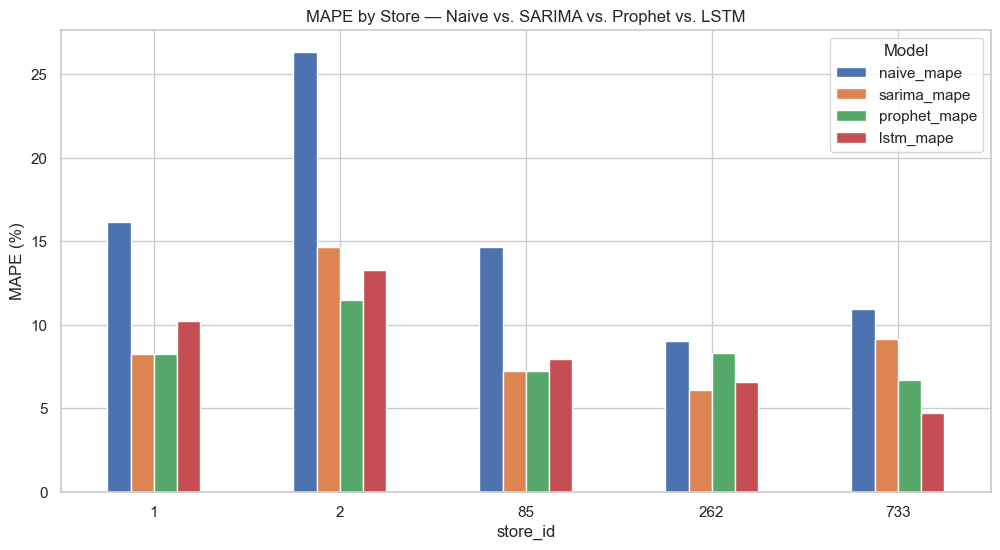

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
full_comparison.plot(kind="bar", ax=ax)
ax.set_title("MAPE by Store — Naive vs. SARIMA vs. Prophet vs. LSTM")
ax.set_ylabel("MAPE (%)")
ax.legend(title="Model")
plt.xticks(rotation=0)
plt.show()

<a id="sec-10"></a>
## 10. Save Model & Scaler

Both the trained model and the fitted scalers are needed at inference
time — predictions must be scaled with the *same* scaler used in training,
and outputs must be inverse-transformed the same way.

In [20]:
import pickle
import os

os.makedirs("../models", exist_ok=True)

model.save("../models/lstm_pooled_model.keras")

with open("../models/lstm_feature_scaler.pkl", "wb") as f:
    pickle.dump(feature_scaler, f)
with open("../models/lstm_target_scaler.pkl", "wb") as f:
    pickle.dump(target_scaler, f)

print("Saved LSTM model and scalers to ../models/")

Saved LSTM model and scalers to ../models/


In [21]:
import json

registry_path = "../models/model_registry.json"
registry = {}
if os.path.exists(registry_path) and os.path.getsize(registry_path) > 0:
    with open(registry_path) as f:
        registry = json.load(f)

registry["lstm_pooled"] = {
    "store_ids": SAMPLE_STORE_IDS,
    "lookback_days": LOOKBACK,
    "feature_columns": FEATURE_COLS,
    "overall_mape": lstm_metrics["MAPE"],
    "per_store_mape": per_store_mape.to_dict(),
    "model_path": "models/lstm_pooled_model.keras",
    "feature_scaler_path": "models/lstm_feature_scaler.pkl",
    "target_scaler_path": "models/lstm_target_scaler.pkl",
}

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)

print(f"Updated {registry_path}")

Updated ../models/model_registry.json
